## Anomaly Detection Model Selection via Statistical Diagnostics

We've trained several anomaly detection models to identify sales drops in hourly retail data. The next step is critical: determining which configuration delivers the most reliable and actionable results.

Generating a large volume of anomaly alerts is trivial. Ensuring those alerts represent genuine, operationally meaningful deviations is the actual challenge. A model that triggers on every zero-sale interval provides no value. Similarly, a model that overwhelms analysts with excessive daily alerts undermines its own utility. The goal is to isolate configurations that detect *real* sales deterioration with both statistical rigor and practical restraint.

This notebook implements a structured evaluation framework to achieve that.

### Approach: Statistical Diagnostics Over Subjective Judgment

In the absence of large-scale ground-truth labels, we apply a statistics-driven methodology. Each detected anomaly is enriched with historical context from the pre-test period and evaluated across three dimensions:

**Signal strength.**  
An anomaly that deviates marginally from expected behavior is not actionable. We compute z-scores against two reference baselines for every flagged event: the product's entire pre-test history and its performance during July alone — the last complete month of normal operations before the test window. Higher absolute z-score values indicate stronger, non-random deviations. We specifically measure the proportion of anomalies exceeding |z| > 2 and |z| > 3, widely accepted thresholds for statistically noteworthy and extreme outliers, respectively.

**Anomaly composition.**  
The nature of flagged events matters as much as their magnitude. We track the percentage of anomalies where sales are zero — a high share suggests the model is capturing routine non-trading patterns rather than genuine drops. We also measure the proportion of severe declines, defined as deviations greater than 50% below historical norms. Critically, we verify that stock was available at the time of each anomaly; a properly functioning detection system should only flag events where product was present to sell.

**Operational viability.**  
Even a statistically perfect model fails in practice if its output is unmanageable. We assess total alert volume, breadth of product coverage, and average daily alert frequency. Beyond sheer numbers, we validate the temporal profile of detected anomalies — all events should concentrate within working hours and skew toward weekdays, confirming that the mandatory preprocessing filters function correctly across all model configurations.

### Models Under Evaluation

Seven configurations spanning three architectures — LightGBM, Temporal Convolutional Network (TCN), and Isolation Forest — are subjected to this framework. Configurations differ in their threshold mechanisms: some rely on standard deviation-based cutoffs, others on z-score-based thresholds.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

DATA_PATH = r'C:\Users\User\Desktop\диплом\data_v1.csv'

MODELS = {
    'LightGBM_sigma5':   r'C:\Users\User\Desktop\диплом\detected_anomalies_august_lgbm_5.csv',
    'LightGBM_sigma3_5': r'C:\Users\User\Desktop\диплом\detected_anomalies_august_lgbm_3_5.csv',
    'LightGBM_zscore_4_5': r'C:\Users\User\Desktop\диплом\detected_anomalies_august_lgbm_z_4_5.csv',
    'TCN_sigma_5':        r'C:\Users\User\Desktop\диплом\tcn_anomalies_5.csv',
    'TCN_sigma_3_5':      r'C:\Users\User\Desktop\диплом\tcn_anomalies_3_5.csv',
    'TCN_zscore_4_5':      r'C:\Users\User\Desktop\диплом\TCN_zscore_4_5.csv',
    'Isolation_forest': r'C:\Users\User\Desktop\диплом\isolation_forest_final_an.csv',
    'Imredi': r'C:\\Users\\User\\Desktop\\диплом\\target_sample.csv'
}

# Load full original dataset for statistical baseline computation

In [2]:
df_full = pd.read_csv(DATA_PATH)
df_full['date'] = pd.to_datetime(df_full['date'])
df_full['product'] = df_full['product'].astype(str)
print(f"Dataset shape: {df_full.shape}, period: {df_full['date'].min()} — {df_full['date'].max()}")

Dataset shape: (64081080, 6), period: 2025-01-15 00:00:00 — 2025-12-27 23:00:00


# Evaluation function — enriches anomalies with statistical context and computes quality metrics

In [3]:
def evaluate_anomaly_set(anomaly_df, full_df, model_name="Model", test_start="2025-08-01"):

    # Historical statistics per product (pre-test period, starting from first positive sale)
    pre_test = full_df[full_df['date'] < test_start].copy()

    first_pos = (pre_test[pre_test['sales'] > 0]
                 .groupby('product')['date'].min()
                 .reset_index(name='first_positive_date'))

    pre_test = pre_test.merge(first_pos, on='product', how='left')
    pre_test = pre_test[pre_test['date'] >= pre_test['first_positive_date']].copy()

    stats_full = pre_test.groupby('product').agg(
        mean_sales_hist   = ('sales', 'mean'),
        std_sales_hist    = ('sales', 'std'),
        median_sales_hist = ('sales', 'median'),
        pos_rate_hist     = ('sales', lambda x: (x > 0).mean()),
    ).reset_index()

    stats_july = (pre_test[pre_test['date'].dt.month == 7]
                  .groupby('product').agg(
                      mean_sales_july = ('sales', 'mean'),
                      std_sales_july  = ('sales', 'std'),
                  ).reset_index())

    # Enrich anomalies with historical context
    anom = anomaly_df.copy()
    anom['date']    = pd.to_datetime(anom['date'])
    anom['product'] = anom['product'].astype(str)
    anom['hour']    = anom['date'].dt.hour
    anom['weekday'] = anom['date'].dt.dayofweek

    anom = anom.merge(stats_full, on='product', how='left')
    anom = anom.merge(stats_july, on='product', how='left')

    # Avoid division by zero
    for col in ['std_sales_hist', 'std_sales_july', 'mean_sales_hist', 'mean_sales_july']:
        anom[col] = anom[col].replace(0, np.nan).fillna(1)

    # Z-scores
    anom['z_hist'] = (anom['sales'] - anom['mean_sales_hist']) / anom['std_sales_hist']
    anom['z_july'] = (anom['sales'] - anom['mean_sales_july']) / anom['std_sales_july']

    # Percentage deviation from baselines
    anom['dev_pct_hist'] = (anom['sales'] - anom['mean_sales_hist']) / anom['mean_sales_hist'] * 100
    anom['dev_pct_july'] = (anom['sales'] - anom['mean_sales_july']) / anom['mean_sales_july'] * 100

    # Previous-hour stock
    stock_prev = (full_df[['date', 'product', 'stocks']]
                  .rename(columns={'stocks': 'stocks_prev', 'date': 'prev_date'}))
    anom['prev_date'] = anom['date'] - pd.Timedelta(hours=1)
    anom = anom.merge(stock_prev, on=['prev_date', 'product'], how='left')

    # Masks
    drop_mask      = anom['sales'] < anom['mean_sales_hist']
    zero_mask      = anom['sales'] == 0
    deep_drop_mask = anom['dev_pct_hist'] < -50
    stock_ok_mask  = (anom['stocks_prev'] > 0) & (anom['stocks'] > 0)

    n = len(anom)

    # Quality metrics
    metrics = {
        'Model': model_name,

        'Anomalies found': n,
        'Unique products': anom['product'].nunique(),
        'Unique days': anom['date'].dt.date.nunique(),
        'Anomalies/day (avg)': round(n / max(anom['date'].dt.date.nunique(), 1), 1),

        'Mean deviation from norm (%)': round(anom.loc[drop_mask, 'dev_pct_hist'].mean(), 1),
        'Median deviation from norm (%)': round(anom.loc[drop_mask, 'dev_pct_hist'].median(), 1),
        'Mean deviation from July (%)': round(anom.loc[drop_mask, 'dev_pct_july'].mean(), 1),

        'Mean |z_hist|': round(anom['z_hist'].abs().mean(), 3),
        'Mean |z_july|': round(anom['z_july'].abs().mean(), 3),
        '% |z_hist| > 2': round((anom['z_hist'].abs() > 2).mean() * 100, 1),
        '% |z_hist| > 3': round((anom['z_hist'].abs() > 3).mean() * 100, 1),
        '% |z_july| > 2': round((anom['z_july'].abs() > 2).mean() * 100, 1),
        '% |z_july| > 3': round((anom['z_july'].abs() > 3).mean() * 100, 1),

        '% zero sales': round(zero_mask.mean() * 100, 1),
        '% drops > 50% below norm': round(deep_drop_mask.mean() * 100, 1),
        '% anomalies with stock': round(stock_ok_mask.mean() * 100, 1),

        'Peak hour (mode)': int(anom['hour'].mode().iloc[0]),
        '% working hours (7–22)': round(((anom['hour'] >= 7) & (anom['hour'] <= 22)).mean() * 100, 1),
        '% weekdays': round((anom['weekday'] < 5).mean() * 100, 1),
    }

    return metrics, anom

# Run evaluation across all models

In [4]:
all_metrics = []
all_anom    = {}

for model_name, model_path in MODELS.items():
    anom_df = pd.read_csv(model_path)
    anom_df['date'] = pd.to_datetime(anom_df['date'])

    metrics, anom_enriched = evaluate_anomaly_set(
        anomaly_df  = anom_df,
        full_df     = df_full,
        model_name  = model_name,
        test_start  = "2025-08-01"
    )
    all_metrics.append(metrics)
    all_anom[model_name] = anom_enriched
    print(f"{model_name}: {metrics['Anomalies found']} anomalies, "
          f"{metrics['Unique products']} products, "
          f"mean |z_hist| = {metrics['Mean |z_hist|']}")

LightGBM_sigma5: 926 anomalies, 142 products, mean |z_hist| = 0.667
LightGBM_sigma3_5: 1869 anomalies, 221 products, mean |z_hist| = 0.603
LightGBM_zscore_4_5: 948 anomalies, 138 products, mean |z_hist| = 8.191
TCN_sigma_5: 996 anomalies, 43 products, mean |z_hist| = 0.471
TCN_sigma_3_5: 1658 anomalies, 81 products, mean |z_hist| = 0.461
TCN_zscore_4_5: 1128 anomalies, 179 products, mean |z_hist| = 8.82
Isolation_forest: 5146 anomalies, 38 products, mean |z_hist| = 2.279
Imredi: 1194 anomalies, 494 products, mean |z_hist| = 0.569


Model,LightGBM_sigma5,LightGBM_sigma3_5,LightGBM_zscore_4_5,TCN_sigma_5,TCN_sigma_3_5,TCN_zscore_4_5,Isolation_forest,Imredi
Anomalies found,926.000000,1869.000000,948.000000,996.000000,1658.000000,1128.000000,5146.000000,1194.000000
Unique products,142.000000,221.000000,138.000000,43.000000,81.000000,179.000000,38.000000,494.000000
Unique days,30.000000,30.000000,30.000000,25.000000,25.000000,25.000000,30.000000,24.000000
Anomalies/day (avg),30.900000,62.300000,31.600000,39.800000,66.300000,45.100000,171.500000,49.800000
Mean deviation from norm (%),-86.500000,-90.300000,nan,-69.500000,-75.500000,nan,-61.300000,-99.800000
Median deviation from norm (%),-100.000000,-100.000000,nan,-93.700000,-100.000000,nan,-59.700000,-100.000000
Mean deviation from July (%),-90.800000,-93.100000,nan,-77.200000,-81.200000,nan,-71.900000,-99.600000
Mean |z_hist|,0.667000,0.603000,8.191000,0.471000,0.461000,8.820000,2.279000,0.569000
Mean |z_july|,0.612000,0.561000,6.413000,0.489000,0.484000,7.161000,1.810000,0.527000
% |z_hist| > 2,5.200000,4.400000,96.600000,1.400000,1.000000,96.600000,35.900000,5.700000


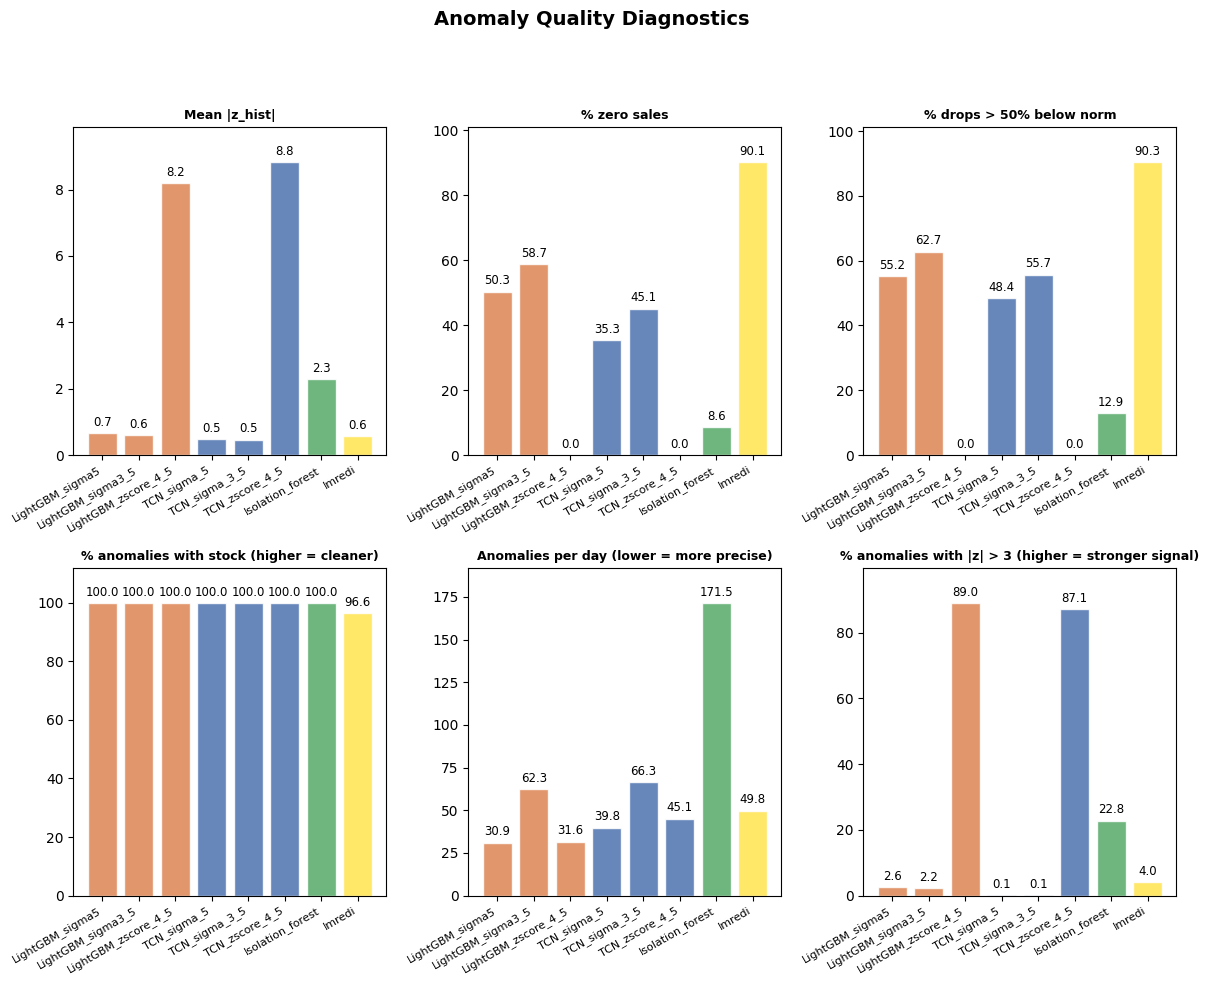

In [17]:
summary = pd.DataFrame(all_metrics).set_index('Model').T
display(summary.style.set_caption("Model Comparison — Signal Quality Diagnostics")
        .set_properties(**{'text-align': 'center', 'font-size': '11px'}))

fig, axes = plt.subplots(2, 3, figsize=(12, 10))
axes = axes.flatten()

names = [m['Model'] for m in all_metrics]

def get_color(model_name: str) -> str:
    name = model_name.lower()
    if 'lightgbm' in name or 'lgbm' in name:
        return '#DD8452'
    elif 'tcn' in name:
        return '#4C72B0'
    elif 'isolation' in name or 'forest' in name:
        return '#55A868'
    elif 'imredi' in name:
        return '#ffe34d'
    return '#DD8452'

colors = [get_color(name) for name in names]

plots = [
    ('Mean |z_hist|', 'Mean |z_hist|'),
    ('% zero sales', '% zero sales'),
    ('% drops > 50% below norm', '% drops > 50% below norm'),
    ('% anomalies with stock', '% anomalies with stock (higher = cleaner)'),
    ('Anomalies/day (avg)', 'Anomalies per day (lower = more precise)'),
    ('% |z_hist| > 3', '% anomalies with |z| > 3 (higher = stronger signal)'),
]

for ax, (metric, title) in zip(axes, plots):
    vals = [m[metric] for m in all_metrics]
    bars = ax.bar(names, vals, color=colors, alpha=0.85, edgecolor='white')
    
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=8)
    
    if vals:
        max_val = max(vals)
        ax.set_ylim(0, max_val * 1.12)
    
    # Подписи над барами
    for bar, val in zip(bars, vals):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, 
                height + max_val * 0.015,
                f'{val:.1f}' if isinstance(val, float) else str(val),
                ha='center', va='bottom', fontsize=8.5, fontweight='medium')

plt.suptitle('Anomaly Quality Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Benchmarking rationale

July serves as the **reference baseline for normal product behavior**. The z-score captures how far August sales deviate from the same product's July mean. A z_july of -4.5 means sales dropped 4.5 standard deviations below the July norm. This is more sensitive than z_hist, since full history may contain seasonal fluctuations, while July provides fresh context immediately preceding the test period.

## Results overview

The seven configurations fall into three distinct clusters:

**Cluster 1 — zscore_4.5 (LightGBM & TCN):** dramatically stronger signal. Mean |z_hist| = 8.19 and 8.82 — 13–19× higher than all other models. |z|>3 share: 89% and 87%. Zero-sale share: 0% for both — these models catch real drops at non-zero sales, not trivial zeros. This is fundamentally important.

**Cluster 2 — sigma=5 and sigma=3.5 (LightGBM & TCN):** weak signal (mean |z_hist| < 0.7), over half of anomalies are zero sales — normal for many products. These thresholds essentially detect "product didn't sell this hour" rather than "sales dropped abnormally."

**Cluster 3 — Isolation Forest:** moderate signal (mean |z_hist| = 2.28), but finds 5,146 anomalies on only 38 products — catastrophic concentration (171 anomalies/day on a tiny product set). The narrowest coverage of all.

**Head-to-head, LightGBM_zscore_4.5 vs. TCN_zscore_4.5:** TCN has a marginally higher z-score (8.82 vs. 8.19), but LightGBM covers more products (138) with fewer daily alerts (31.6 vs. 45.1) — broader yet more restrained coverage. LightGBM also trains orders of magnitude faster and requires far less computational resources than the TCN neural network.

## Conclusion

Based on the combined criteria — statistical signal strength, product coverage breadth, and alert frequency restraint — **LightGBM with zscore = -4.5** is selected for further development. It delivers the best balance between signal precision and assortment coverage, while its architecture provides result interpretability and flexible feature engineering for subsequent iterations.